In [1]:
!pip install pennylane
!pip install torchinfo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 63.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 65.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 58.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 75.0 MB/s eta 0:00:00:00:0100:01


In [2]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from datetime import timedelta

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models

from sklearn.metrics import *
from tqdm.auto import tqdm

import pennylane as qml
from torchinfo import summary

# Precision settings
np.set_printoptions(precision=3)
torch.set_printoptions(precision=3)

In [3]:
IMG_SIZE = 224
BATCH_SIZE = 6  
EPOCHS = 15
LR = 0.00005      
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [4]:
CSV_PATH = "/kaggle/input/datasets/farjanakabirsamanta/skin-cancer-dataset/HAM10000_metadata.csv"
IMG_DIR = "/kaggle/input/datasets/farjanakabirsamanta/skin-cancer-dataset/Skin Cancer/Skin Cancer"

In [5]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

In [6]:
class SkinCancerDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

        self.classes = sorted(self.df['dx'].unique())
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        self.df['label'] = self.df['dx'].map(self.class_to_idx)

        self.image_paths, self.labels = [], []

        for _, row in self.df.iterrows():
            path = os.path.join(self.img_dir, row['image_id'] + ".jpg")
            if os.path.exists(path):
                self.image_paths.append(path)
                self.labels.append(row['label'])

        print(f"Total images: {len(self.image_paths)}")

    def __len__(self): return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

In [7]:
full_dataset = SkinCancerDataset(CSV_PATH, IMG_DIR, transform)

CLASSES = full_dataset.classes
num_classes = len(CLASSES)

train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

Total images: 10015


In [8]:
n_qubits = 2
n_layers = 2

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):

    # 🔹 DATA ENCODING (Angle Encoding)
    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)

    # 🔹 VARIATIONAL LAYERS
    for l in range(n_layers):

        # Rotation layer
        for i in range(n_qubits):
            qml.RX(weights[l, i], wires=i)
            qml.RZ(weights[l, i], wires=i)

        # 🔹 ENTANGLEMENT (chain + ring)
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i+1])
        qml.CNOT(wires=[n_qubits-1, 0])  # ring

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]


class QuantumLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(n_layers, n_qubits))

    def forward(self, x):
        outputs = []
        for i in range(x.shape[0]):
            out = quantum_circuit(x[i], self.weights)
            out = torch.stack(out).float()
            outputs.append(out)
        return torch.stack(outputs)

In [9]:
class HybridMobileNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        base = models.mobilenet_v2(weights="DEFAULT")
        self.features = base.features

        # Freeze 50%
        freeze_layers = len(self.features)//2
        for i in range(freeze_layers):
            for p in self.features[i].parameters():
                p.requires_grad = False

        # Quantum branch
        self.q_branch = nn.Sequential(
            nn.Conv2d(160, 40, 1),
            nn.BatchNorm2d(40),
            nn.ReLU(),

            nn.Conv2d(40, 8, 3, padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1,1))
        )

        self.q_fc = nn.Linear(8, n_qubits)
        self.quantum = QuantumLayer()

        # Classical enhancement
        self.extra = nn.Sequential(
            nn.Conv2d(1280,128,1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )

        self.final_fc = nn.Linear(32 + n_qubits, num_classes)

    def forward(self,x):
        x = self.features[:17](x)

        # Quantum
        q = self.q_branch(x)
        q = torch.flatten(q,1)
        q = torch.tanh(self.q_fc(q))
        q = self.quantum(q)

        # Classical
        c = self.features[17:](x)
        c = self.extra(c)
        c = nn.functional.adaptive_avg_pool2d(c,(1,1))
        c = torch.flatten(c,1)

        out = torch.cat([c,q],dim=1)
        return self.final_fc(out)

In [10]:
model = HybridMobileNet(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 125MB/s]


In [11]:
def custom_metrics(y_pred, y_true, loss):
    y_pred = torch.argmax(y_pred,1)

    y_true = y_true.cpu().numpy()
    y_pred = y_pred.cpu().numpy()

    return {
        "loss": round(loss,3),
        "accuracy": round(accuracy_score(y_true,y_pred),3)
    }

In [12]:
train_hist = {"loss":[],"accuracy":[]}
val_hist = {"loss":[],"accuracy":[]}

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    model.train()
    train_loss=0
    preds, labels = [],[]

    for x,y in tqdm(train_loader):
        x,y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out,y)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds.append(out)
        labels.append(y)

    preds = torch.cat(preds)
    labels = torch.cat(labels)

    train_metrics = custom_metrics(preds,labels,train_loss/len(train_loader))
    train_hist["loss"].append(train_metrics["loss"])
    train_hist["accuracy"].append(train_metrics["accuracy"])

    print("Train:", {k:f"{v:.3f}" for k,v in train_metrics.items()})

    # VALIDATION
    model.eval()
    val_loss=0
    preds, labels = [],[]

    with torch.no_grad():
        for x,y in val_loader:
            x,y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out,y)

            val_loss += loss.item()
            preds.append(out)
            labels.append(y)

    preds = torch.cat(preds)
    labels = torch.cat(labels)

    val_metrics = custom_metrics(preds,labels,val_loss/len(val_loader))
    val_hist["loss"].append(val_metrics["loss"])
    val_hist["accuracy"].append(val_metrics["accuracy"])

    print("Val:", {k:f"{v:.3f}" for k,v in val_metrics.items()})


Epoch 1/15


  0%|          | 0/1169 [00:00<?, ?it/s]

Train: {'loss': '1.487', 'accuracy': '0.591'}
Val: {'loss': '0.976', 'accuracy': '0.752'}

Epoch 2/15


  0%|          | 0/1169 [00:00<?, ?it/s]

Train: {'loss': '0.979', 'accuracy': '0.726'}
Val: {'loss': '0.717', 'accuracy': '0.777'}

Epoch 3/15


...

Train: {'loss': '0.220', 'accuracy': '0.946'}
Val: {'loss': '0.601', 'accuracy': '0.829'}

Epoch 14/15


  0%|          | 0/1169 [00:00<?, ?it/s]

Train: {'loss': '0.202', 'accuracy': '0.950'}
Val: {'loss': '0.536', 'accuracy': '0.839'}

Epoch 15/15


  0%|          | 0/1169 [00:00<?, ?it/s]

Train: {'loss': '0.167', 'accuracy': '0.960'}
Val: {'loss': '0.520', 'accuracy': '0.845'}


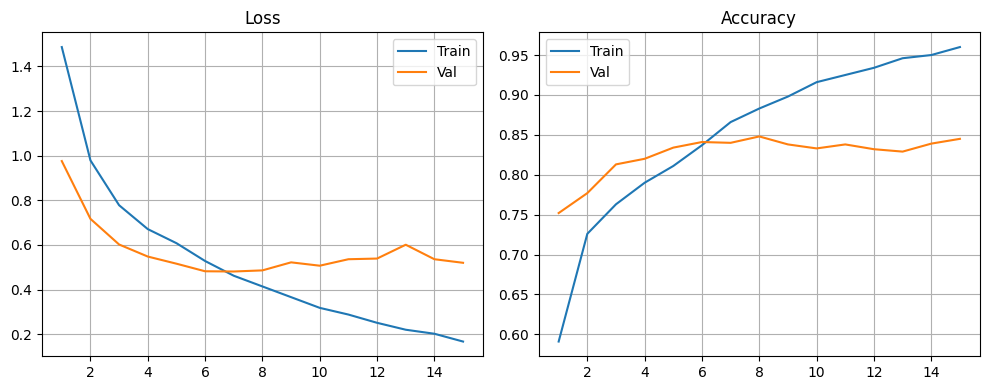

In [13]:
epochs = range(1,len(train_hist["loss"])+1)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(epochs,train_hist["loss"],label="Train")
plt.plot(epochs,val_hist["loss"],label="Val")
plt.title("Loss")
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.plot(epochs,train_hist["accuracy"],label="Train")
plt.plot(epochs,val_hist["accuracy"],label="Val")
plt.title("Accuracy")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [14]:
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        out = model(x)

        all_preds.append(out)
        all_labels.append(y)

all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

pred_classes = torch.argmax(all_preds, dim=1)

# Classification Report (3 decimal precision)
report = classification_report(
    all_labels.cpu(),
    pred_classes.cpu(),
    target_names=CLASSES,
    digits=3
)

print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(report)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

       akiec      0.574     0.625     0.598        56
         bcc      0.705     0.544     0.614        79
         bkl      0.815     0.639     0.716       158
          df      0.812     0.650     0.722        20
         mel      0.543     0.466     0.502       163
          nv      0.885     0.950     0.916      1008
        vasc      0.833     0.789     0.811        19

    accuracy                          0.826      1503
   macro avg      0.738     0.666     0.697      1503
weighted avg      0.818     0.826     0.819      1503



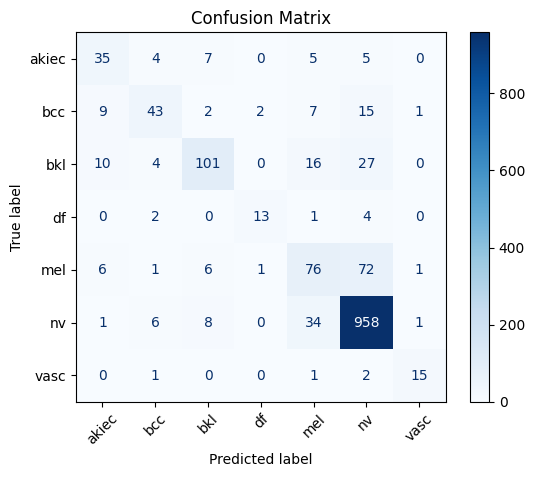

In [15]:
cm = confusion_matrix(all_labels.cpu(), pred_classes.cpu())

disp = ConfusionMatrixDisplay(cm, display_labels=CLASSES)
disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix")
plt.show()

In [16]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print("\n" + "="*40)
print(f"{'Total Parameters:':<25} {total_params:,}")
print(f"{'Trainable Parameters:':<25} {trainable_params:,}")
print(f"{'Frozen Parameters:':<25} {frozen_params:,}")
print("="*40)


Total Parameters:         2,434,747
Trainable Parameters:     2,303,931
Frozen Parameters:        130,816


In [4]:
# Define number of output classes
NUM_CLASSES =7   # change this based on your dataset
from torchinfo import summary

model = HybridMobileNet(num_classes=NUM_CLASSES)
summary(model, input_size=(1, 3, 224, 224))


NameError: name 'HybridMobileNet' is not defined

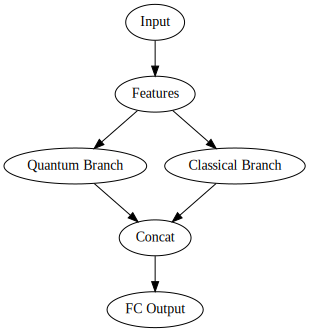

In [1]:

from graphviz import Digraph

dot = Digraph()

dot.node('Input')
dot.node('Features')
dot.node('Quantum Branch')
dot.node('Classical Branch')
dot.node('Concat')
dot.node('FC Output')

dot.edge('Input', 'Features')
dot.edge('Features', 'Quantum Branch')
dot.edge('Features', 'Classical Branch')
dot.edge('Quantum Branch', 'Concat')
dot.edge('Classical Branch', 'Concat')
dot.edge('Concat', 'FC Output')

dot.render('model_architecture', format='png')
dot


In [2]:
import torch

def print_layer_shapes(model, input_size=(1, 3, 224, 224)):
    x = torch.randn(input_size)
    
    print("🔍 Layer-wise Tensor Shapes:\n")
    
    for name, layer in model.named_children():
        try:
            x = layer(x)
            print(f"{name}: {x.shape}")
        except:
            print(f"{name}: skipped (custom/complex layer)")
    
    return x

model = HybridMobileNet(num_classes=NUM_CLASSES)
print_layer_shapes(model)

NameError: name 'HybridMobileNet' is not defined

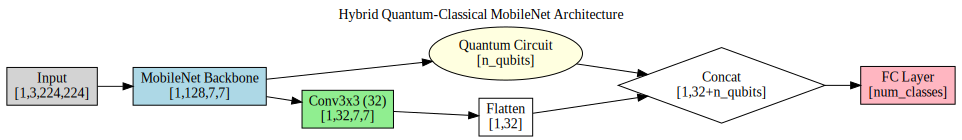

In [3]:
from graphviz import Digraph

dot = Digraph(format='svg')
dot.attr(rankdir='LR', fontsize='14', labelloc="t",
         label="Hybrid Quantum-Classical MobileNet Architecture")

# Nodes
dot.node('Input', 'Input\n[1,3,224,224]', shape='box', style='filled', fillcolor='lightgray')
dot.node('Backbone', 'MobileNet Backbone\n[1,128,7,7]', shape='box', style='filled', fillcolor='lightblue')

dot.node('QBranch', 'Quantum Circuit\n[n_qubits]', shape='ellipse', style='filled', fillcolor='lightyellow')
dot.node('CBranch', 'Conv3x3 (32)\n[1,32,7,7]', shape='box', style='filled', fillcolor='lightgreen')

dot.node('Flatten', 'Flatten\n[1,32]', shape='box')
dot.node('Concat', 'Concat\n[1,32+n_qubits]', shape='diamond')
dot.node('FC', 'FC Layer\n[num_classes]', shape='box', style='filled', fillcolor='lightpink')

# Edges
dot.edge('Input', 'Backbone')
dot.edge('Backbone', 'QBranch')
dot.edge('Backbone', 'CBranch')
dot.edge('CBranch', 'Flatten')
dot.edge('Flatten', 'Concat')
dot.edge('QBranch', 'Concat')
dot.edge('Concat', 'FC')

# Save
dot.render('ieee_architecture_diagram', view=False)
dot